In [1]:
%load_ext autoreload
%autoreload 2

import data_analysis as da

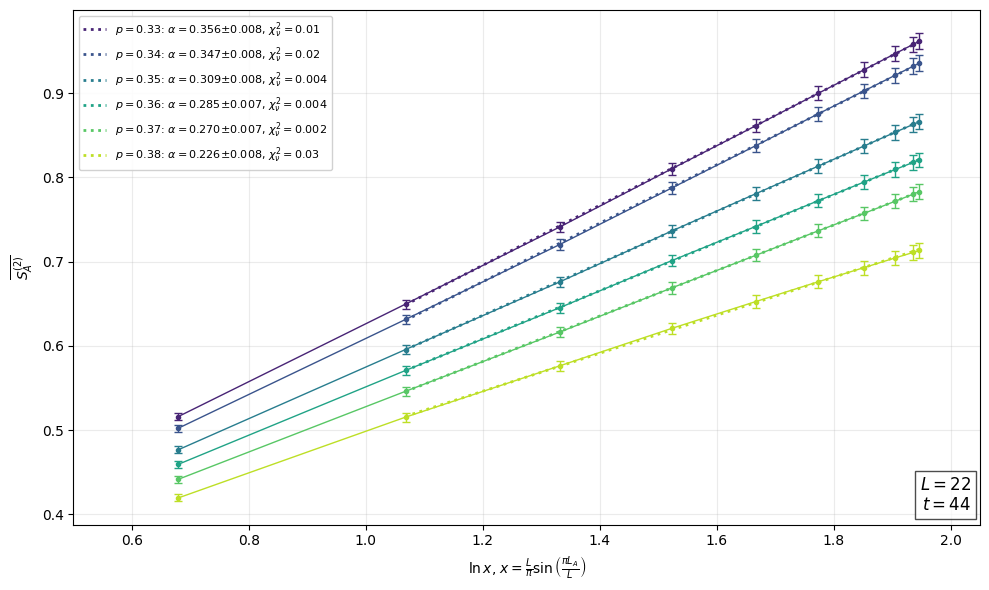

In [2]:
entropy_files = [
    f"cpp/csv/entropy/entropy_n22_p{p}_circ2_real1000.csv"
    for p in ["0.33", "0.34", "0.35", "0.36", "0.37", "0.38"]
]

entropy = da.entropy(
    entropy_files,
    fit_above_p=0.30,
    exclude_first=1,
    uncertainty="S2_stderr",
)

/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/fssa/__init__.py:83: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Importing L=12: cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv
Importing L=16: cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv
Importing L=20: cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv
p-grid alignment: interpolated, 11 points
p_c = 0.355 ± 0.016
nu  = 2.9442552 ± 3
zeta = 0 fixed
collapse quality S = 17.589208
The collapse is very poor under the assumed scaling ansatz.


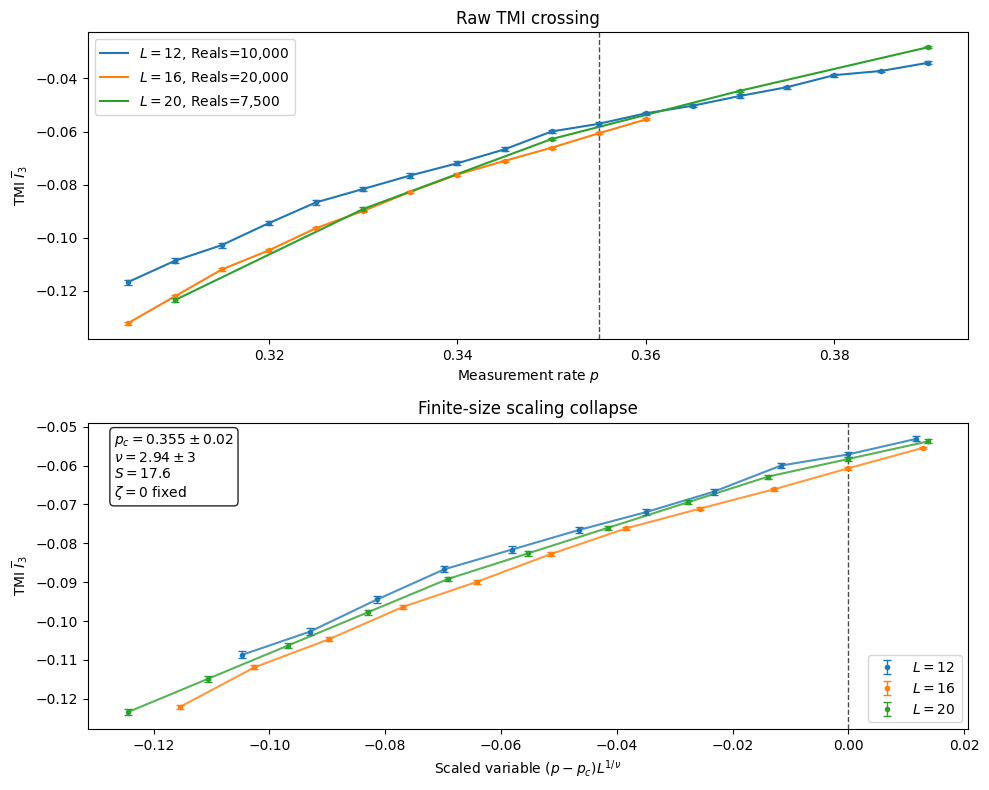

In [3]:
tmi = da.tmi_collapse(
    files=[
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv",
    ],
    sizes=[12, 16, 20],
    realizations=[10_000, 20_000, 7_500],
    p_range=(0.30, 0.39),
    pc0=0.33,
    nu0=2.0,
    fit_zeta=False,
)

Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
z   = 1.046634 ± 0.008548
x_A = 0.226635 ± 0.006439
collapse score = 0.414211


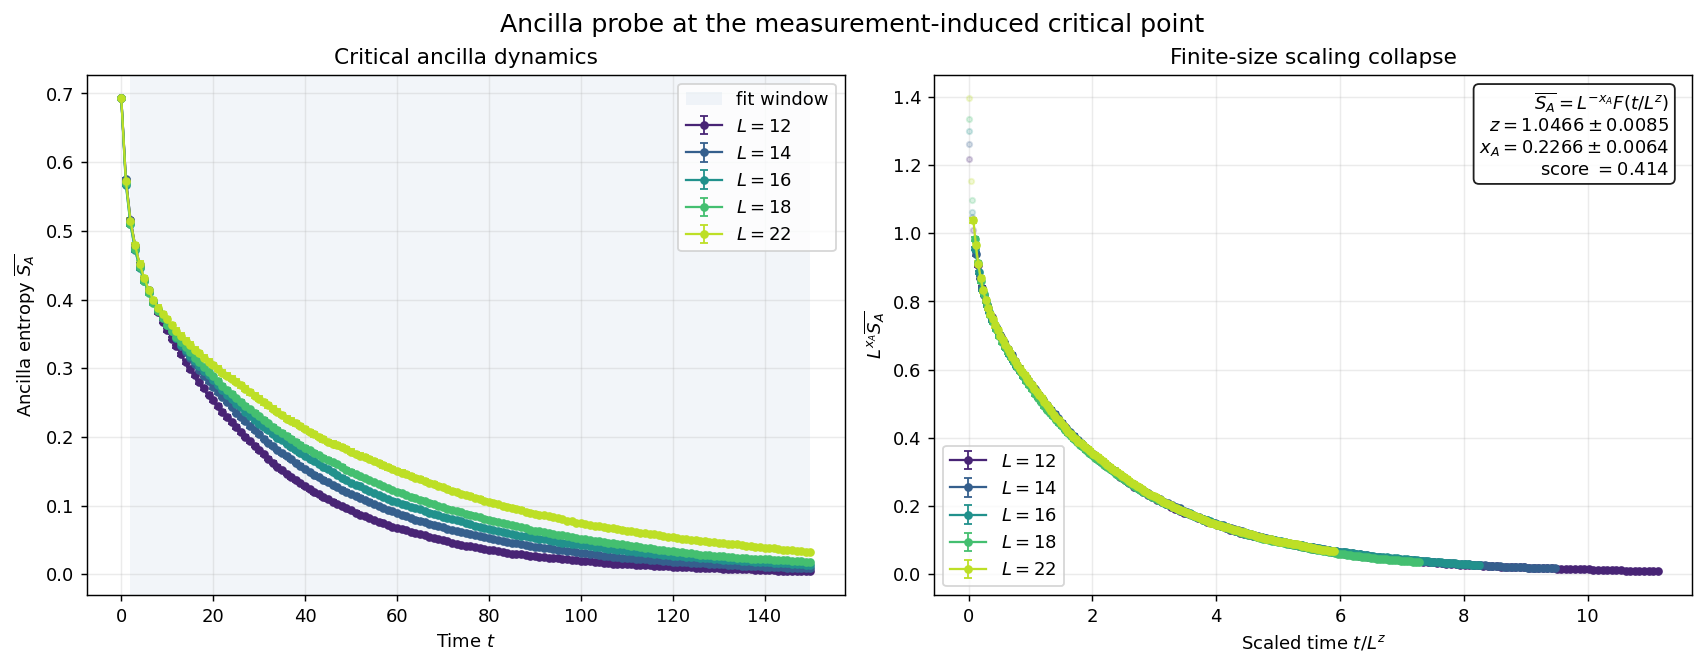

In [5]:
probe1 = da.probe1_collapse(
    file_glob="cpp/csv/probed/t_150/probed_rppu_n_*_p_0.333_d_1_*.csv",
    t_max=150,
    fit_t=(2, None),
    fixed_x_a=None,               # None fits both z and x_A
    z_bounds=(0.4, 2.5),
    bootstrap_samples=200,
    collapse_xscale="linear",
)

,L,p_from_filename,points,x_min,x_max,I_max,x_at_I_max,file
0,12,0.333,97,0.0,8.0,0.539278,8.000000,cpp/csv/2probed/2probed_rppu_n_12_p_0.333_real...
1,14,0.333,113,0.0,8.0,0.540513,8.000000,cpp/csv/2probed/2probed_rppu_n_14_p_0.333_real...
2,16,0.333,129,0.0,8.0,0.527837,8.000000,cpp/csv/2probed/2probed_rppu_n_16_p_0.333_real...
3,18,0.333,145,0.0,8.0,0.527018,7.944444,cpp/csv/2probed/2probed_rppu_n_18_p_0.333_real...
4,20,0.333,161,0.0,8.0,0.487410,7.950000,cpp/csv/2probed/2probed_rppu_n_20_p_0.333_real...


Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
eta = 0.154420 ± 0.010359
bootstrap 68% interval = [0.144919, 0.165992]
collapse score = 0.41995


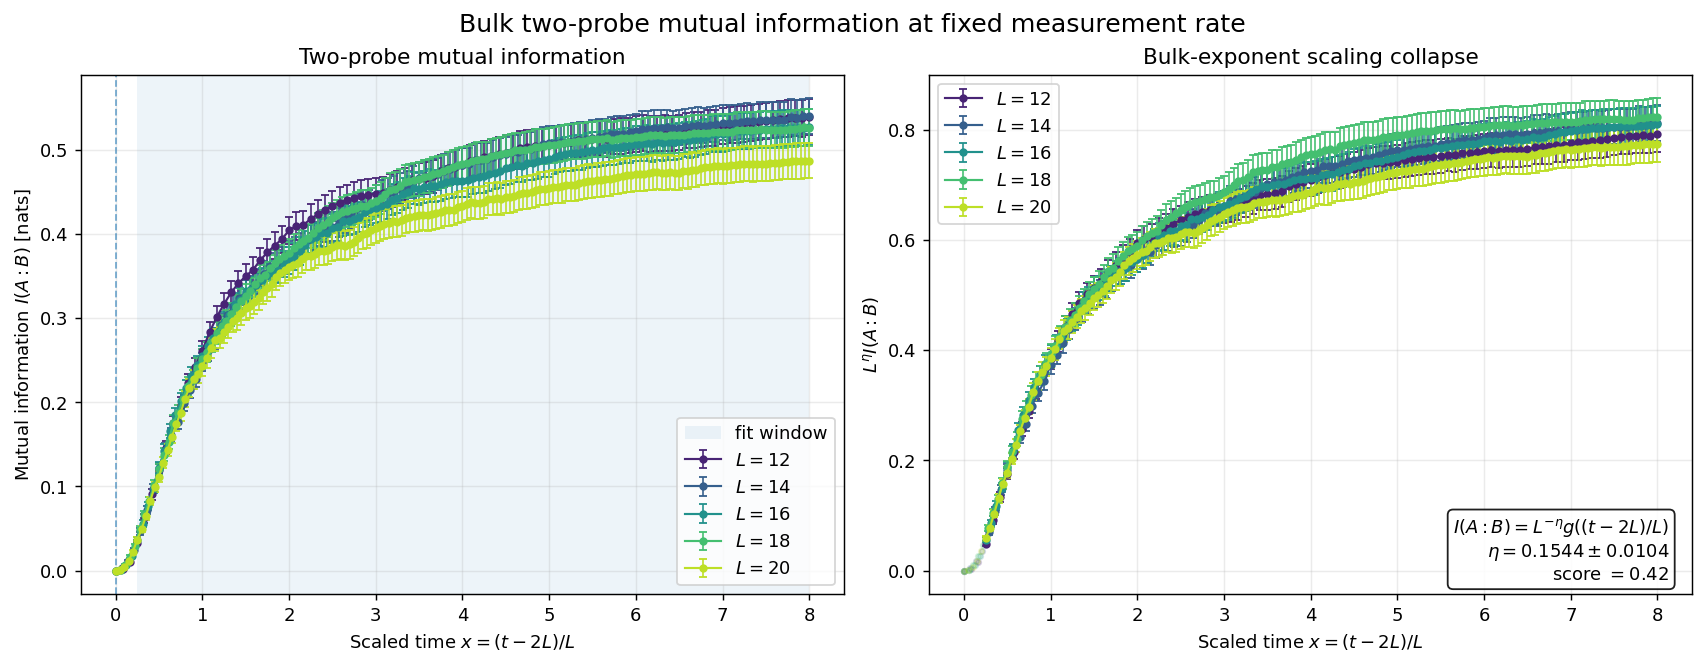

In [6]:
probe2 = da.probe2_collapse(
    file_glob="cpp/csv/2probed/2probed_rppu_n_*_p_0.333_*.csv",
    x_load=(None, None),
    fit_x=(0.25, 8.0),
    fit_i_min=1e-8,
    eta_bounds=(0.0, 2.0),
    bootstrap_samples=200,
)